In [1]:
import os, random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
DATA_DIR = "/kaggle/input/datasets/arnavr10880/concrete-crack-images-for-classification"
OUT_DIR = "/kaggle/working"
IMG_SIZE = (227, 227)
BATCH_SIZE = 64
EPOCHS = 12
SEED = 42
CLASSES = ["Negative", "Positive"]  # 0 = no crack, 1 = crack

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
paths, labels = [], []
for label, cls in enumerate(CLASSES):
    folder = os.path.join(DATA_DIR, cls)
    for f in os.listdir(folder):
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            paths.append(os.path.join(folder, f))
            labels.append(label)
paths, labels = np.array(paths), np.array(labels)
print(f"Total images: {len(paths)}")


Total images: 40000


In [4]:
train_p, temp_p, train_y, temp_y = train_test_split(
    paths, labels, test_size=0.40, stratify=labels, random_state=SEED
)
val_p, test_p, val_y, test_y = train_test_split(
    temp_p, temp_y, test_size=0.50, stratify=temp_y, random_state=SEED
)
print(f"Train: {len(train_p)} | Val: {len(val_p)} | Test: {len(test_p)}")

# حفظ التقسيمة عشان نقدر نعيد التقييم على نفس الـ test set
for name, p, y in [("train", train_p, train_y), ("val", val_p, val_y), ("test", test_p, test_y)]:
    pd.DataFrame({"path": p, "label": y}).to_csv(f"{OUT_DIR}/{name}_split.csv", index=False)


Train: 24000 | Val: 8000 | Test: 8000


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img.set_shape((*IMG_SIZE, 3))
    return img, tf.cast(label, tf.float32)

def make_ds(p, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((p, y))
    if training:
        ds = ds.shuffle(len(p), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_ds(train_p, train_y, training=True)
val_ds = make_ds(val_p, val_y)
test_ds = make_ds(test_p, test_y)

I0000 00:00:1790597581.916569      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790597581.919553      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [6]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)
    return x

def build_model():
    inputs = layers.Input(shape=(*IMG_SIZE, 3))
    x = layers.Rescaling(1.0 / 255)(inputs)
    for f in (32, 64, 128, 256):
        x = conv_block(x, f)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    return models.Model(inputs, outputs, name="crack_cnn")

model = build_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy",
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")],
)
model.summary()

Model: "crack_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 227, 227, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 227, 227, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 227, 227, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 227, 227, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 227, 227, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 113, 113, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 113, 113, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 113, 113, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 406,369 (1.55 MB)

 Trainable params: 405,409 (1.55 MB)

 Non-trainable params: 960 (3.75 KB)

In [7]:
cbs = [
    callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
    callbacks.ModelCheckpoint(f"{OUT_DIR}/best_crack_cnn.keras", monitor="val_loss", save_best_only=True),
]
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=cbs)


Epoch 1/12
  1/375 ━━━━━━━━━━━━━━━━━━━━ 1:33:01 15s/step - accuracy: 0.5156 - loss: 0.7575 - precision: 0.4727 - recall: 0.9286

I0000 00:00:1790597599.557984      68 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


375/375 ━━━━━━━━━━━━━━━━━━━━ 242s 608ms/step - accuracy: 0.9822 - loss: 0.0585 - precision: 0.9848 - recall: 0.9796 - val_accuracy: 0.5014 - val_loss: 3.0133 - val_precision: 1.0000 - val_recall: 0.0027 - learning_rate: 0.0010
Epoch 2/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 53s 142ms/step - accuracy: 0.9924 - loss: 0.0263 - precision: 0.9929 - recall: 0.9919 - val_accuracy: 0.6595 - val_loss: 0.7368 - val_precision: 1.0000 - val_recall: 0.3190 - learning_rate: 0.0010
Epoch 3/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 53s 140ms/step - accuracy: 0.9942 - loss: 0.0188 - precision: 0.9945 - recall: 0.9939 - val_accuracy: 0.9319 - val_loss: 0.1778 - val_precision: 0.8828 - val_recall: 0.9960 - learning_rate: 0.0010
Epoch 4/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 53s 142ms/step - accuracy: 0.9945 - loss: 0.0170 - precision: 0.9948 - recall: 0.9942 - val_accuracy: 0.5166 - val_loss: 1.7278 - val_precision: 0.5085 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 5/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 53s 140ms/step - accur

In [8]:
model.save(f"{OUT_DIR}/crack_cnn_final.keras")
pd.DataFrame(history.history).to_csv(f"{OUT_DIR}/history.csv", index=False)


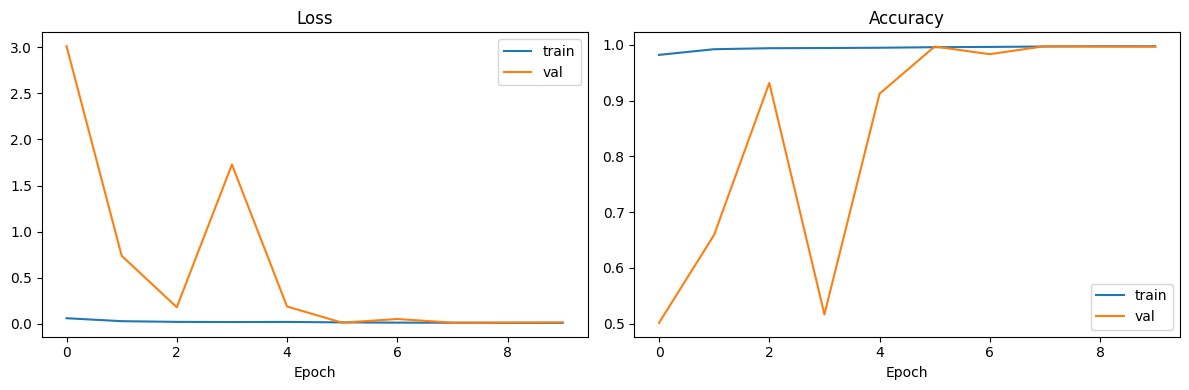

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history["loss"], label="train")
ax[0].plot(history.history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("Epoch"); ax[0].legend()
ax[1].plot(history.history["accuracy"], label="train")
ax[1].plot(history.history["val_accuracy"], label="val")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("Epoch"); ax[1].legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/training_curves.png", dpi=150)
plt.show()



=== Test evaluation ===
125/125 ━━━━━━━━━━━━━━━━━━━━ 68s 542ms/step - accuracy: 0.9973 - loss: 0.0100 - precision: 0.9977 - recall: 0.9967
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step
              precision    recall  f1-score   support

    Negative     0.9968    0.9978    0.9973      4000
    Positive     0.9977    0.9968    0.9972      4000

    accuracy                         0.9972      8000
   macro avg     0.9973    0.9972    0.9972      8000
weighted avg     0.9973    0.9972    0.9972      8000

Confusion matrix:
 [[3991    9]
 [  13 3987]]


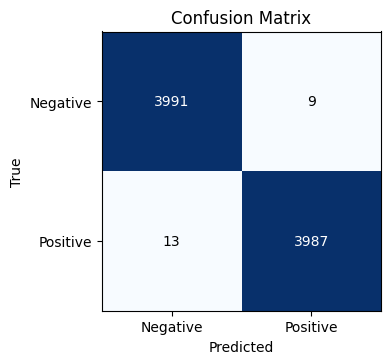


Saved files: ['test_split.csv', 'crack_cnn_final.keras', 'confusion_matrix.png', 'history.csv', 'train_split.csv', 'val_split.csv', 'training_curves.png', '__notebook__.ipynb', 'best_crack_cnn.keras']


In [10]:
print("\n=== Test evaluation ===")
model.evaluate(test_ds)

y_prob = model.predict(test_ds).ravel()
y_pred = (y_prob > 0.5).astype(int)
print(classification_report(test_y, y_pred, target_names=CLASSES, digits=4))

cm = confusion_matrix(test_y, y_pred)
print("Confusion matrix:\n", cm)

plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap="Blues")
plt.xticks([0, 1], CLASSES); plt.yticks([0, 1], CLASSES)
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/confusion_matrix.png", dpi=150)
plt.show()

print("\nSaved files:", os.listdir(OUT_DIR))